In [16]:
# import the necessary packages
from matplotlib import pyplot as plt
import numpy as np
import argparse
import imutils
import cv2

In [17]:
def plt_imshow(title, image):
    # convert the image frame BGR to RGB color space and display it
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.title(title)
    plt.grid(False)
    plt.show()

### Implementing our FFT blur detector with OpenCV

In [18]:
def detect_blur_fft(image, size=60, thresh=10, vis=False):
    # grab the dimensions of the image and use the dimensions to
    # derive the center (x, y)-coordinates
    h, w = image.shape
    cX, cY = (int(w / 2.0), int(h / 2.0))

    # compute the FFT to find the frequency transform, then shift
    # the zero frequency component (i.e., DC component located at
    # the top-left corner) to the center where it will be more
    # easy to analyze
    fft = np.fft.fft2(image)
    fftShift = np.fft.fftshift(fft)

    # check to see if we are visualizing our output
    if vis:
        # compute the magnitude spectrum of the transform
        magnitude = 20 * np.log(np.abs(fftShift))

        # display the original input image
        fig, ax = plt.subplots(
            1,
            2,
        )
        ax[0].imshow(image, cmap="gray")
        ax[0].set_title("Input")
        ax[0].set_xticks([])
        ax[0].set_yticks([])

        # display the magnitude image
        ax[1].imshow(magnitude, cmap="gray")
        ax[1].set_title("Magnitude Spectrum")
        ax[1].set_xticks([])
        ax[1].set_yticks([])

        # show our plots
        plt.show()

        # zero-out the center of the FFT shift (i.e., remove low
    # frequencies), apply the inverse shift such that the DC
    # component once again becomes the top-left, and then apply
    # the inverse FFT
    fftShift[cY - size : cY + size, cX - size : cX + size] = 0
    fftShift = np.fft.ifftshift(fftShift)
    recon = np.fft.ifft2(fftShift)

    # compute the magnitude spectrum of the reconstructed image,
    # then compute the mean of the magnitude values
    magnitude = 20 * np.log(np.abs(recon))
    mean = np.mean(magnitude)

    # the image will be considered "blurry" if the mean value of the
    # magnitudes is less than the threshold value
    return (mean, mean <= thresh)

### Detecting blur in images with FFT

In [19]:
# construct the argument parser and parse the arguments
# ap = argparse.ArgumentParser()
# ap.add_argument("-i", "--image", type=str, required=True,
# 	help="path input image that we'll detect blur in")
# ap.add_argument("-t", "--thresh", type=int, default=20,
# 	help="threshold for our blur detector to fire")
# ap.add_argument("-v", "--vis", type=int, default=-1,
# 	help="whether or not we are visualizing intermediary steps")
# ap.add_argument("-d", "--test", type=int, default=-1,
# 	help="whether or not we should progressively blur the image")
# args = vars(ap.parse_args())

# since we are using Jupyter Notebooks we can replace our argument
# parsing code with *hard coded* arguments and values
args = {"image": "images/jemma.png", "thresh": 20, "vis": -1, "test": -1}

In [20]:
# load the input image from disk, resize it, and convert it to
# grayscale
orig = cv2.imread(args["image"])
orig = imutils.resize(orig, width=500)
gray = cv2.cvtColor(orig, cv2.COLOR_BGR2GRAY)

# apply our blur detector using the FFT
mean, blurry = detect_blur_fft(
    gray, size=60, thresh=args["thresh"], vis=args["vis"] > 0
)

[INFO] Blurry (12.4738)


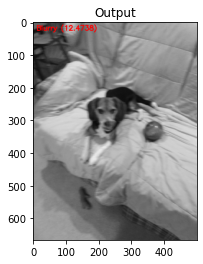

In [21]:
# draw on the image, indicating whether or not it is blurry
image = np.dstack([gray] * 3)
color = (0, 0, 255) if blurry else (0, 255, 0)
text = "Blurry ({:.4f})" if blurry else "Not Blurry ({:.4f})"
text = text.format(mean)
cv2.putText(image, text, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
print("[INFO] {}".format(text))

# show the output image
plt_imshow("Output", image)

In [22]:
# check to see if are going to test our FFT blurriness detector using
# various sizes of a Gaussian kernel
if args["test"] > 0:
    # loop over various blur radii
    for radius in range(1, 30, 2):
        # clone the original grayscale image
        image = gray.copy()

        # check to see if the kernel radius is greater than zero
        if radius > 0:
            # blur the input image by the supplied radius using a
            # Gaussian kernel
            image = cv2.GaussianBlur(image, (radius, radius), 0)

            # apply our blur detector using the FFT
            mean, blurry = detect_blur_fft(
                image, size=60, thresh=args["thresh"], vis=args["vis"] > 0
            )

            # draw on the image, indicating whether or not it is
            # blurry
            image = np.dstack([image] * 3)
            color = (0, 0, 255) if blurry else (0, 255, 0)
            text = "Blurry ({:.4f})" if blurry else "Not Blurry ({:.4f})"
            text = text.format(mean)
            cv2.putText(image, text, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            print("[INFO] Kernel: {}, Result: {}".format(radius, text))

        # show the image
        plt_imshow("Test Image", image)

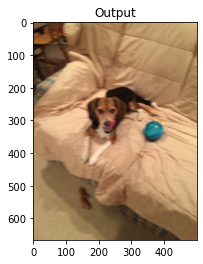

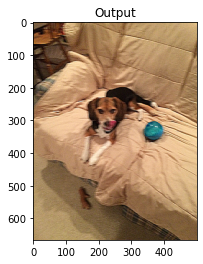

In [24]:
sharpen_kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
sharpen = cv2.filter2D(orig, -1, sharpen_kernel)
plt_imshow("Original", orig)
plt_imshow("Output", sharpen)